# Hafta 5 — Sayısal Türev ve İntegral (Kuadratür)

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib

Elimizde yalnızca *değerlendirebildiğimiz* bir fonksiyon varken (elle türevini/integralini alamadığımız), türevi veya integrali nasıl hesaplarız? Bu hafta:

1. Türevler için **sonlu farklar** ve "sadece $h$'yi minik yap" yaklaşımını yanlış kılan **yuvarlama–kesme ödünleşimi**.
2. Baştaki hata terimlerini sadeleştirip doğruluğu fırlatan **Richardson ekstrapolasyonu**.
3. **Newton–Cotes** kuadratürü: orta nokta, yamuk, Simpson — ve hata mertebeleri.
4. **Bileşik** kurallar ve fonksiyonun zor olduğu yere çaba harcayan **uyarlamalı (adaptive)** kuadratür.
5. Verili nokta sayısıyla mümkün olan en yüksek polinom doğruluğunu sağlayan **Gauss kuadratürü**.

1. haftanın temaları keskin biçimde geri döner: türev almak *kötü koşullu* bir işlemdir, integral almak ise *iyi koşulludur* — ve matematik bunun nedenini tam olarak açıklar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Sonlu farklar ve optimal adım boyu

Taylor açılımı üç klasik şablonu verir:

$$ \text{ileri: } f'(x)\approx\frac{f(x+h)-f(x)}{h} = f'(x) + \mathcal{O}(h), $$
$$ \text{merkezi: } f'(x)\approx\frac{f(x+h)-f(x-h)}{2h} = f'(x) + \mathcal{O}(h^2). $$

**Kesme hatası** $h$ küçüldükçe azalır. Ama her fonksiyon değeri $\sim u\,|f|$ yuvarlama hatası taşır ve $h$'ye böleriz — dolayısıyla **yuvarlama hatası** $u/h$ gibi büyür. Toplam hata, sweet spot'u olan U-biçimli bir eğridir:

$$ \text{toplam} \approx \underbrace{C h^p}_{\text{kesme}} + \underbrace{\frac{u}{h}}_{\text{yuvarlama}}. $$

$h$'yi mümkün olduğunca küçültmek klasik bir acemi hatasıdır. U'yu *görelim*.


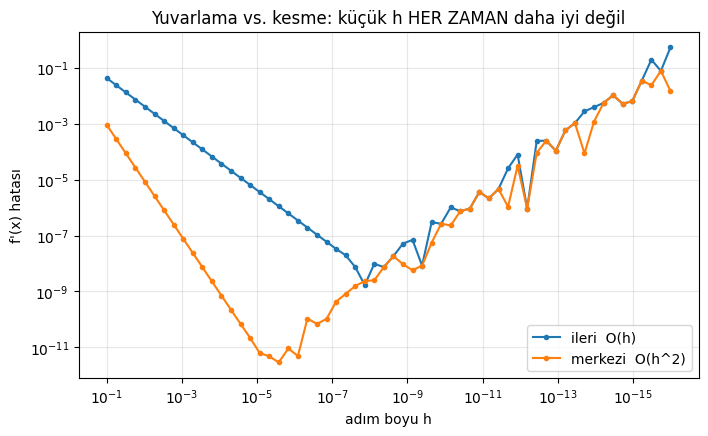

en iyi ileri h ~ 1.3664483492953271e-08  (teori ~ sqrt(u) = 1.0488088481701515e-08 )
en iyi merkezi h ~ 2.6529484644318946e-06  (teori ~ u^(1/3) = 4.791419857062787e-06 )


In [2]:
def ileri_fark(f, x, h): return (f(x+h) - f(x)) / h
def merkezi_fark(f, x, h): return (f(x+h) - f(x-h)) / (2*h)

f, df = np.sin, np.cos
x0 = 1.0
hs = np.logspace(-1, -16, 60)
hata_ileri = np.abs(ileri_fark(f, x0, hs) - df(x0))
hata_merkezi = np.abs(merkezi_fark(f, x0, hs) - df(x0))

fig, ax = plt.subplots()
ax.loglog(hs, hata_ileri, ".-", label="ileri  O(h)")
ax.loglog(hs, hata_merkezi, ".-", label="merkezi  O(h^2)")
ax.invert_xaxis()
ax.set_xlabel("adım boyu h"); ax.set_ylabel("f'(x) hatası")
ax.set_title("Yuvarlama vs. kesme: küçük h HER ZAMAN daha iyi değil")
ax.legend(); plt.show()

print("en iyi ileri h ~", hs[np.argmin(hata_ileri)], " (teori ~ sqrt(u) =", np.sqrt(1.1e-16), ")")
print("en iyi merkezi h ~", hs[np.argmin(hata_merkezi)], " (teori ~ u^(1/3) =", (1.1e-16)**(1/3), ")")


Minimumlar tam da teorinin öngördüğü yerde: ileri şablon için $h^\star \sim \sqrt{u}$, merkezi şablon için $h^\star \sim u^{1/3}$. Bunun ötesinde yuvarlama baskındır ve $h$ küçüldükçe doğruluk *bozulur*. Bu, sayısal türev hakkındaki en önemli pratik gerçektir.

## 2. Richardson ekstrapolasyonu

Bir yöntemin hatası $A(h) = A_0 + c\,h^p + \mathcal{O}(h^{p+1})$ ise, baştaki terimi *sadeleştirmek* için iki adım boyunu birleştirebiliriz. Merkezi fark için ($p=2$):

$$ A_0 \approx \frac{2^p A(h/2) - A(h)}{2^p - 1}. $$

Bunu yinelemek çok yüksek mertebeye tırmanan bir tablo kurar — ileride **Romberg integrasyonunun** altında yatan fikir.


In [3]:
def richardson(f, x, h, p=2, seviye=4):
    T = np.zeros((seviye, seviye))
    for i in range(seviye):
        T[i, 0] = merkezi_fark(f, x, h / 2**i)
    for j in range(1, seviye):
        for i in range(j, seviye):
            carpan = 2.0**(p*j)
            T[i, j] = (carpan * T[i, j-1] - T[i-1, j-1]) / (carpan - 1)
    return T

T = richardson(np.sin, 1.0, 0.4, p=2, seviye=5)
gercek = np.cos(1.0)
print("sütun 0 (düz merkezi fark) hataları:", np.abs(T[:, 0] - gercek))
print("köşegen (ekstrapole)       hataları:", np.abs(np.diag(T) - gercek))


sütun 0 (düz merkezi fark) hataları: [1.42932351e-02 3.59481820e-03 9.00053698e-04 2.25097822e-04
 5.62797314e-05]
köşegen (ekstrapole)       hataları: [1.42932351e-02 2.86792231e-05 6.84100088e-09 2.36921593e-13
 1.44328993e-15]


Köşegen, ham sütundan kat kat daha doğrudur — Richardson ekstrapolasyonu *aynı* fonksiyon değerlendirmelerinden çok daha fazla doğruluk çıkarır.

## 3. Newton–Cotes kuadratürü

$\int_a^b f(x)\,dx$ yaklaşıklamak için $f$'yi bir interpolasyon polinomuyla değiştirip onu integre edin. Eşit aralıklı düğümler **Newton–Cotes** ailesini verir. Genişliği $h$ olan tek bir aralıkta:

- **Orta nokta**: hata $\mathcal{O}(h^3 f'')$
- **Yamuk**: hata $\mathcal{O}(h^3 f'')$
- **Simpson**: hata $\mathcal{O}(h^5 f^{(4)})$ — kübikler için kesin!


In [4]:
def yamuk(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5*y[0] + y[1:-1].sum() + 0.5*y[-1])

def simpson(f, a, b, n):
    if n % 2: n += 1                          # Simpson çift sayıda panel ister
    x = np.linspace(a, b, n+1)
    y = f(x)
    h = (b - a) / n
    return h/3 * (y[0] + y[-1] + 4*y[1:-1:2].sum() + 2*y[2:-2:2].sum())

g = lambda x: np.exp(-x**2)
a, b = 0.0, 2.0
kesin = 0.8820813907624215           # erf temelli referans
print(f"yamuk   (n=100): {yamuk(g, a, b, 100):.12f}  hata {abs(yamuk(g,a,b,100)-kesin):.2e}")
print(f"simpson (n=100): {simpson(g, a, b, 100):.12f}  hata {abs(simpson(g,a,b,100)-kesin):.2e}")


yamuk   (n=100): 0.882078948840  hata 2.44e-06
simpson (n=100): 0.882081390111  hata 6.51e-10


### Yakınsama mertebesi, görselleştirilmiş

$h$'yi yarılamak yamuk hatasını $4\times$ ($\mathcal{O}(h^2)$ küresel), Simpson hatasını $16\times$ ($\mathcal{O}(h^4)$) azaltmalı. Log–log grafikte eğim mertebeyi doğrudan açığa çıkarır.


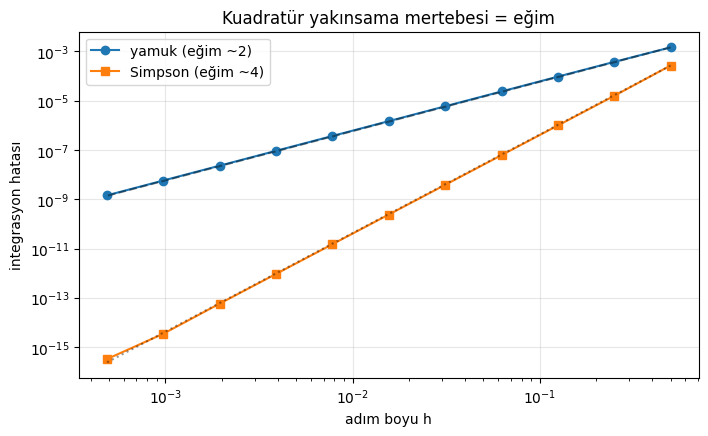

In [5]:
ns = 2 ** np.arange(2, 13)
hs = (b - a) / ns
hata_yamuk = [abs(yamuk(g, a, b, n) - kesin) for n in ns]
hata_simp = [abs(simpson(g, a, b, n) - kesin) for n in ns]

fig, ax = plt.subplots()
ax.loglog(hs, hata_yamuk, "o-", label="yamuk (eğim ~2)")
ax.loglog(hs, hata_simp, "s-", label="Simpson (eğim ~4)")
ax.loglog(hs, hs**2 * hata_yamuk[0]/hs[0]**2, "k--", alpha=0.4)
ax.loglog(hs, hs**4 * hata_simp[0]/hs[0]**4, "k:", alpha=0.4)
ax.set_xlabel("adım boyu h"); ax.set_ylabel("integrasyon hatası")
ax.set_title("Kuadratür yakınsama mertebesi = eğim"); ax.legend(); plt.show()


## 4. Uyarlamalı kuadratür

Sabit bir ızgara pürüzsüz bölgelerde çaba boşa harcar, keskin bölgelerde yetersiz çözünürlük verir. **Uyarlamalı** kuadratür yalnızca yerel bir hata kestirimi toleransı aştığı yerlerde özyinelemeli olarak böler. Tüm aralıktaki Simpson'ı iki yarısındaki Simpson ile karşılaştırırız; tolerumdan fazla anlaşamazlarsa özyineleriz.


In [6]:
def uyarlamali_simpson(f, a, b, tol=1e-10, derinlik=50):
    def _simpson(fa, fm, fb, a, b):
        return (b - a) / 6 * (fa + 4*fm + fb)
    def _ozyinele(a, b, fa, fm, fb, butun, tol, derinlik):
        m = 0.5*(a+b)
        sm, sgm = 0.5*(a+m), 0.5*(m+b)
        fsm, fsgm = f(sm), f(sgm)
        sol = _simpson(fa, fsm, fm, a, m)
        sag = _simpson(fm, fsgm, fb, m, b)
        if derinlik <= 0 or abs(sol + sag - butun) <= 15*tol:
            return sol + sag + (sol + sag - butun)/15   # Richardson düzeltmesi
        return (_ozyinele(a, m, fa, fsm, fm, sol, tol/2, derinlik-1)
                + _ozyinele(m, b, fm, fsgm, fb, sag, tol/2, derinlik-1))
    fa, fb = f(a), f(b)
    m = 0.5*(a+b); fm = f(m)
    butun = _simpson(fa, fm, fb, a, b)
    return _ozyinele(a, b, fa, fm, fb, butun, tol, derinlik)

# Düzgün ızgaraları cezalandıran keskin tepeli bir fonksiyon.
tepe = lambda x: np.exp(-100*(x-0.5)**2)
deger = uyarlamali_simpson(tepe, 0, 1, tol=1e-12)
ref_ince = simpson(tepe, 0, 1, 200000)
print(f"uyarlamalı Simpson : {deger:.12f}")
print(f"ince düzgün referans: {ref_ince:.12f}")
print(f"fark               : {abs(deger-ref_ince):.2e}")


uyarlamalı Simpson : 0.177245385090
ince düzgün referans: 0.177245385090
fark               : 2.14e-15


## 5. Gauss kuadratürü

Newton–Cotes düğümleri (eşit aralıklı) sabitler ve ağırlıkları çözer. **Gauss–Legendre** kuadratürü *hem* düğümleri *hem* ağırlıkları serbest bırakır ve bunları kuralın $2n-1$ dereceye kadar polinomlar için kesin olacağı şekilde seçer — $n$ noktayla mümkün olan maksimum. Optimal düğümler Legendre polinomlarının kökleri olur. Bunları **Jacobi (Golub–Welsch) matrisinin** özdeğerlerini bularak sıfırdan kurabiliriz.


In [7]:
def gauss_legendre(n):
    # Golub-Welsch: düğümler simetrik üç köşegenli bir matrisin özdeğerleridir.
    k = np.arange(1, n)
    beta = k / np.sqrt(4*k**2 - 1)             # köşegen-dışı girdiler
    J = np.diag(beta, 1) + np.diag(beta, -1)
    dugumler, vekt = np.linalg.eigh(J)
    agirliklar = 2 * vekt[0, :]**2             # ilk özvektör bileşenlerinden ağırlıklar
    return dugumler, agirliklar

def gauss_kuadratur(f, a, b, n):
    x, w = gauss_legendre(n)
    xm = 0.5*(b-a)*x + 0.5*(b+a)               # [-1,1]'den [a,b]'ye eşle
    return 0.5*(b-a) * np.sum(w * f(xm))

g = lambda x: np.exp(-x**2)
print(f"{'n':>3} {'Gauss kestirimi':>20} {'hata':>14}")
for n in [2, 4, 6, 8, 10]:
    est = gauss_kuadratur(g, 0, 2, n)
    print(f"{n:>3} {est:>20.14f} {abs(est-kesin):>14.2e}")


  n      Gauss kestirimi           hata
  2     0.91948611664092       3.74e-02
  4     0.88222909593260       1.48e-04
  6     0.88208135535173       3.54e-08
  8     0.88208139041990       3.43e-10
 10     0.88208139076211       3.14e-13


Yalnızca **10 düğüm** Gauss kuadratürü makine hassasiyetine yaklaşır — düzgün bir Simpson kuralı karşılaştırılabilir doğruluk için binlerce nokta gerektirir. Gauss kuadratürünün çoğu üretim integratörünün altında yatmasının nedeni budur.

## Özet

- Sayısal türevin bir **optimal adım boyu** vardır; daha küçük daha iyi değildir çünkü $u/h$ yuvarlaması sonunda baskın olur.
- **Richardson ekstrapolasyonu** baştaki hata terimlerini ucuz doğruluk kazanımı için sadeleştirir.
- Newton–Cotes kuralları basitliği mertebeyle takas eder: yamuk $\mathcal{O}(h^2)$, Simpson $\mathcal{O}(h^4)$.
- **Uyarlamalı** kuadratür çabayı integrandın zor olduğu yere yoğunlaştırır.
- **Gauss kuadratürü** optimaldir: $n$ düğümle $2n-1$ dereceye kadar kesin.

---

## Alıştırmalar

**1. (Karmaşık adım türevi.)** Karmaşık adım hilesini $f'(x)\approx \mathrm{Im}\,f(x+ih)/h$ kodlayın ve **hiçbir** çıkarmalı sadeleşmesi olmadığını gösterin — sonlu farkların aksine $h\to0$ oldukça doğruluk artar. ($f$'nin karmaşık girdi kabul etmesi gerekir.)

**2. (Romberg.)** Bileşik yamuk kuralını Richardson ekstrapolasyonuyla birleştirip bir Romberg integrasyon tablosu kurun. Köşegenin ilk sütundan çok daha hızlı yakınsadığını gösterin.

**3. (İkinci türevler.)** $f''(x)$ için merkezi şablonu türetip kodlayın, optimal $h$'sini deneysel bulun ve teorinin öngördüğü $u^{1/4}$ ölçeklemesiyle karşılaştırın.

**4. (Tekil integrand.)** $\int_0^1 1/\sqrt{x}\,dx$ integralini alın. Düzgün Simpson'ın neden zorlandığını ve bir değişken değiştirme veya uyarlamalı incelemenin nasıl kurtardığını açıklayın.

**5. (Gauss vs. Newton–Cotes.)** 7. dereceden bir polinom için 4 noktalı Gauss–Legendre'nin *kesin*, 4 noktalı Simpson'ın olmadığını doğrulayın. Sonra ikisini $e^{-x^2}$ üzerinde karşılaştırıp değerlendirme sayısına karşı hatayı çizin.
